# 三周内容综合复习

## 1. 数据获取

需求：获取 TSLA（特斯拉）2025年全年（2025-01-01 至 2026-01-01）的
股票数据，并处理好 yfinance 下载后常见的"多层列名"问题。

In [18]:
import pandas as pd
import sqlite3
import yfinance as yf

In [19]:
data = yf.download('TSLA',start='2025-01-01',end='2026-01-01')
data.columns = data.columns.get_level_values(0)
conn = sqlite3.connect('stock_data.db')
data.to_sql('TSLA',conn,if_exists='replace')

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/yfinance/scrapers/history.py:472: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
[*********************100%***********************]  1 of 1 completed


250

## 2. 数据清洗与对齐

需求：从数据库中取出 TSLA 和 AAPL 的价格数据，分别计算日收益率，
并按日期对齐合并成一张表（用 merge，参考"逐个合并"的思路），
处理合并后产生的空值。

In [20]:
tsla = pd.read_sql("select Date,Close from TSLA",conn)
aapl = pd.read_sql("select Date,Close from AAPL",conn)

tsla['return'] = tsla['Close'].pct_change()
aapl['return'] = aapl['Close'].pct_change()

merged = pd.merge(tsla[['Date','return']],aapl[['Date','return']],on='Date',suffixes=('_tsla','_aapl'))
merged = merged.dropna()

## 3. SQL存储与查询

需求：查看当前数据库里有哪些表；用SQL语句查询TSLA表中收盘价(Close)
大于300的所有记录，按日期降序排列。

In [21]:
tables = pd.read_sql("select name from sqlite_master where type = 'table' ", conn)


In [23]:
tsla_result = pd.read_sql("select Date,Close from TSLA where Close > 300 order by Date DESC ", conn)


## 4. 描述性分析

需求：基于第2步得到的 merged 表（TSLA和AAPL的收益率数据），
分别计算两只股票的收益率统计概览（均值、标准差等）和波动率。

In [26]:
merged[['return_tsla','return_aapl']].describe()

,return_tsla,return_aapl
count,249.000000,249.000000
mean,0.001471,0.000661
std,0.039880,0.020450
min,-0.154262,-0.092456
25%,-0.021034,-0.006692
50%,0.000342,0.000786
75%,0.024384,0.006577
max,0.226900,0.153289


In [28]:
tsla_std= merged['return_tsla'].std()
aapl_std= merged['return_aapl'].std()
print(tsla_std)
print(aapl_std)

0.03988004213797383
0.02045047059832011


## 5. 可视化

需求：画出TSLA的价格走势图，叠加20日和60日移动平均线，
并解决中文乱码问题。

In [30]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

In [32]:
tsla_price = pd.read_sql('select Date,Close from TSLA',conn)
tsla_price['MA20'] = tsla_price['Close'].rolling(window=20).mean()
tsla_price['MA60'] = tsla_price['Close'].rolling(window=60).mean()

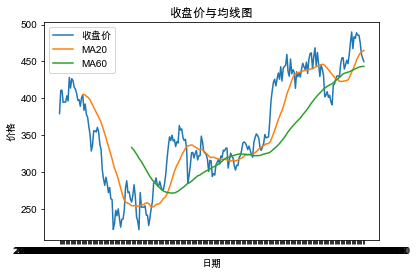

In [34]:
fig,ax = plt.subplots()
ax.plot(tsla_price['Date'],tsla_price['Close'],label='收盘价')
ax.plot(tsla_price['Date'],tsla_price['MA20'],label='MA20')
ax.plot(tsla_price['Date'],tsla_price['MA60'],label='MA60')
ax.set_xlabel('日期')
ax.set_ylabel('价格')
ax.set_title('收盘价与均线图')
ax.legend()
plt.show()

## 6. 回归分析

需求：以标普500（GSPC）作为大盘基准，计算TSLA相对大盘的beta系数，
并画出残差图检验模型是否健康。

In [36]:
gspc = pd.read_sql('select Date,Close from GSPC' ,conn)
gspc['return'] = gspc['Close'].pct_change()

In [39]:
merged2 = pd.merge(tsla[['Date','return']],gspc[['Date','return']],on='Date',suffixes=('_tsla','_gspc'))
merged2 = merged2.dropna()


In [45]:
import statsmodels.api as sm

In [47]:
x = merged2['return_gspc']
y = merged2['return_tsla']
x = sm.add_constant(x)
model = sm.OLS(y,x)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:            return_tsla   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.479
Method:                 Least Squares   F-statistic:                     229.0
Date:                Sat, 19 Sep 2026   Prob (F-statistic):           4.76e-37
Time:                        16:14:33   Log-Likelihood:                 531.11
No. Observations:                 249   AIC:                            -1058.
Df Residuals:                     247   BIC:                            -1051.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0001      0.002     -0.075      

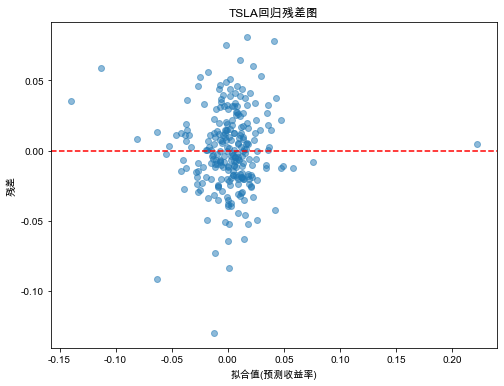

In [51]:
fitted_tsla = result.fittedvalues
residuals_tsla = result.resid
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(fitted_tsla, residuals_tsla, alpha=0.5)
ax.axhline(y=0, color='red', linestyle='--')
ax.set_xlabel('拟合值(预测收益率)')
ax.set_ylabel('残差')
ax.set_title('TSLA回归残差图')
plt.show()

In [55]:
aapl = pd.read_sql('select Date,Close from AAPL' ,conn)
aapl['return_aapl'] = aapl['Close'].pct_change()


In [57]:
merged3 = pd.merge(merged2,aapl[['Date','return_aapl']],on='Date')

In [60]:
corr = merged3[['return_tsla','return_gspc','return_aapl']].corr()


In [62]:
import seaborn as sns


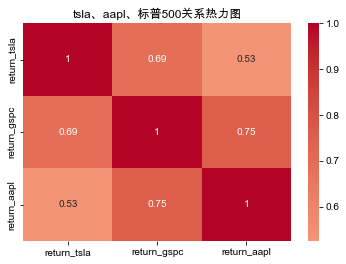

In [65]:
fig,ax=plt.subplots()
sns.heatmap(corr,annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('tsla、aapl、标普500关系热力图')
plt.show()